# 05 Hybrid RGB-FFT-Radial Energy Fusion Model

## CSE 445: Machine Learning Project

**Project Title:** Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis  
**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Notebook Objective

This notebook implements a three-branch spatial-frequency fusion model inspired by recent multi-modal AI-generated image detection research.

Previous experiments showed:

| Model | Input Type | Test Accuracy | F1-score |
|---|---|---:|---:|
| ResNet18 RGB Baseline | RGB image | 87.00% | 87.50% |
| ResNet18 FFT Baseline | FFT magnitude | 65.00% | 67.21% |
| Hybrid RGB-FFT Fusion | RGB + FFT | 84.25% | 84.48% |

The FFT-only model overfitted heavily, and the simple RGB-FFT fusion model did not outperform the RGB baseline.

Therefore, this notebook adds a **radial energy distribution branch** to provide a more structured frequency-domain representation.

# 1. Paper-Inspired Motivation

The FreqCross paper proposes a multi-modal spatial-frequency fusion model for AI-generated image detection.

It uses three complementary feature sources:

1. RGB spatial features
2. 2D FFT magnitude spectrum features
3. Radial energy distribution features

The radial energy profile summarizes how frequency energy is distributed from the center of the FFT spectrum toward outer high-frequency regions.

This notebook implements a practical Kaggle-scale version of this idea:

- **RGB Branch:** Pretrained ResNet18 feature extractor
- **FFT Branch:** Lightweight CNN feature extractor
- **Radial Energy Branch:** MLP feature extractor
- **Fusion Head:** Concatenation followed by a compact classifier

This is not a full reproduction of FreqCross.  
It is a paper-inspired implementation designed for the CSE 445 project setting.

In [1]:
# ============================================================
# 2. Import Required Libraries
# ============================================================

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cu128


In [2]:
# ============================================================
# 3. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Enable GPU before training.")

Using device: cuda
GPU name: Tesla T4


In [3]:
# ============================================================
# 4. Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at: {SEED}")

Random seed fixed at: 42


In [4]:
# ============================================================
# 5. Load Image Paths - Fast Version
# ============================================================

dataset_root = Path("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images")

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

real_paths = []
fake_paths = []

for split_folder in ["train", "test"]:
    real_dir = dataset_root / split_folder / "real"
    fake_dir = dataset_root / split_folder / "fake"
    
    real_paths.extend([
        p for p in real_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])
    
    fake_paths.extend([
        p for p in fake_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])

all_image_paths = real_paths + fake_paths

print(f"Total image files found: {len(all_image_paths)}")
print(f"Real images found: {len(real_paths)}")
print(f"Fake images found: {len(fake_paths)}")

Total image files found: 60000
Real images found: 30000
Fake images found: 30000


In [5]:
# ============================================================
# 6. Balanced Sampling: 2000 Real + 2000 Fake
# ============================================================

N_REAL = 2000
N_FAKE = 2000

real_sample = random.sample(real_paths, N_REAL)
fake_sample = random.sample(fake_paths, N_FAKE)

real_df = pd.DataFrame({
    "image_path": [str(p) for p in real_sample],
    "label": 0,
    "class_name": "real"
})

fake_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_sample],
    "label": 1,
    "class_name": "fake"
})

df = pd.concat([real_df, fake_df], ignore_index=True)
df = shuffle(df, random_state=SEED).reset_index(drop=True)

print("Balanced dataframe created.")
print(df["class_name"].value_counts())

Balanced dataframe created.
class_name
real    2000
fake    2000
Name: count, dtype: int64


In [6]:
# ============================================================
# 7. Train/Validation/Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset split completed.")

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nClass distribution:")
print("Train:")
print(train_df["class_name"].value_counts())
print("\nValidation:")
print(val_df["class_name"].value_counts())
print("\nTest:")
print(test_df["class_name"].value_counts())

Dataset split completed.

Train size: 2400
Validation size: 800
Test size: 800

Class distribution:
Train:
class_name
real    1200
fake    1200
Name: count, dtype: int64

Validation:
class_name
real    400
fake    400
Name: count, dtype: int64

Test:
class_name
real    400
fake    400
Name: count, dtype: int64


# 2. FFT and Radial Energy Feature Extraction

This notebook uses two frequency-domain representations:

## 1. FFT Magnitude Image

The image is converted to grayscale, transformed using FFT, shifted to center the low-frequency components, and converted into a normalized magnitude spectrum image.

## 2. Radial Energy Profile

The radial energy profile summarizes how spectral energy is distributed from the center of the FFT spectrum to the outer frequency bands.

Low-frequency components are near the center.  
High-frequency components are farther from the center.

This provides a compact frequency descriptor that may be more stable than using the full FFT magnitude image alone.

In [7]:
# ============================================================
# 8. FFT Magnitude Spectrum Function
# ============================================================

def image_to_fft_pil(image_path, image_size=(224, 224)):
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    
    image_array = np.array(image)
    
    fft = np.fft.fft2(image_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(fft_shift))
    
    magnitude = magnitude - magnitude.min()
    magnitude = magnitude / (magnitude.max() + 1e-8)
    magnitude = (magnitude * 255).astype(np.uint8)
    
    fft_image = Image.fromarray(magnitude).convert("RGB")
    
    return fft_image

In [8]:
# ============================================================
# 9. Radial Energy Profile Function
# ============================================================

def compute_radial_energy_profile(image_path, image_size=(224, 224), num_bins=32):
    """
    Compute radial energy distribution from the FFT magnitude spectrum.

    Returns:
        radial_profile: numpy array of shape (num_bins,)
    """
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    image_array = np.array(image).astype(np.float32)
    
    fft = np.fft.fft2(image_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    
    h, w = magnitude.shape
    center_y, center_x = h // 2, w // 2
    
    y_indices, x_indices = np.indices((h, w))
    radius = np.sqrt((x_indices - center_x) ** 2 + (y_indices - center_y) ** 2)
    
    max_radius = radius.max()
    bin_edges = np.linspace(0, max_radius, num_bins + 1)
    
    radial_profile = []
    
    for i in range(num_bins):
        mask = (radius >= bin_edges[i]) & (radius < bin_edges[i + 1])
        
        if np.any(mask):
            energy = magnitude[mask].mean()
        else:
            energy = 0.0
        
        radial_profile.append(energy)
    
    radial_profile = np.array(radial_profile, dtype=np.float32)
    
    # Log scaling and normalization
    radial_profile = np.log1p(radial_profile)
    radial_profile = radial_profile - radial_profile.min()
    radial_profile = radial_profile / (radial_profile.max() + 1e-8)
    
    return radial_profile

print("FFT image and radial energy functions defined successfully.")

FFT image and radial energy functions defined successfully.


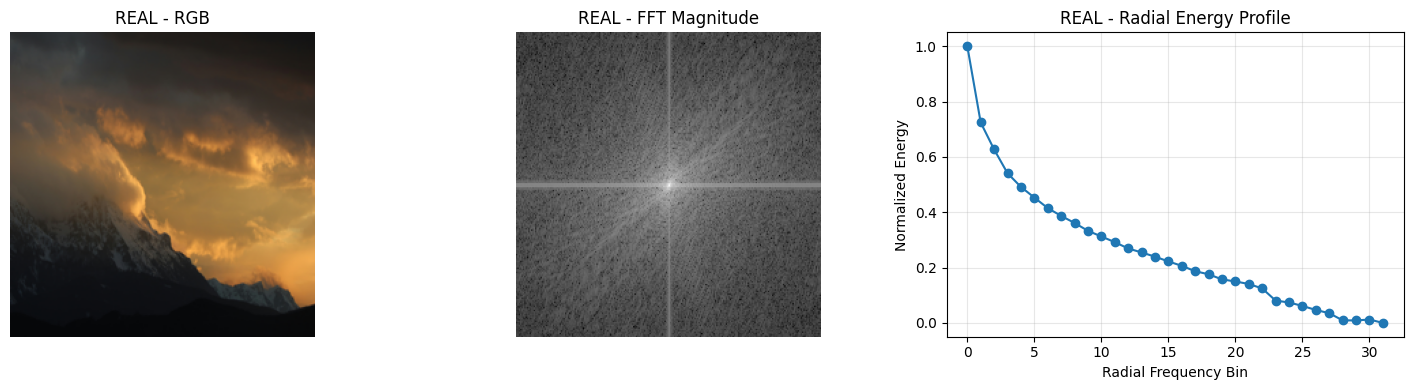

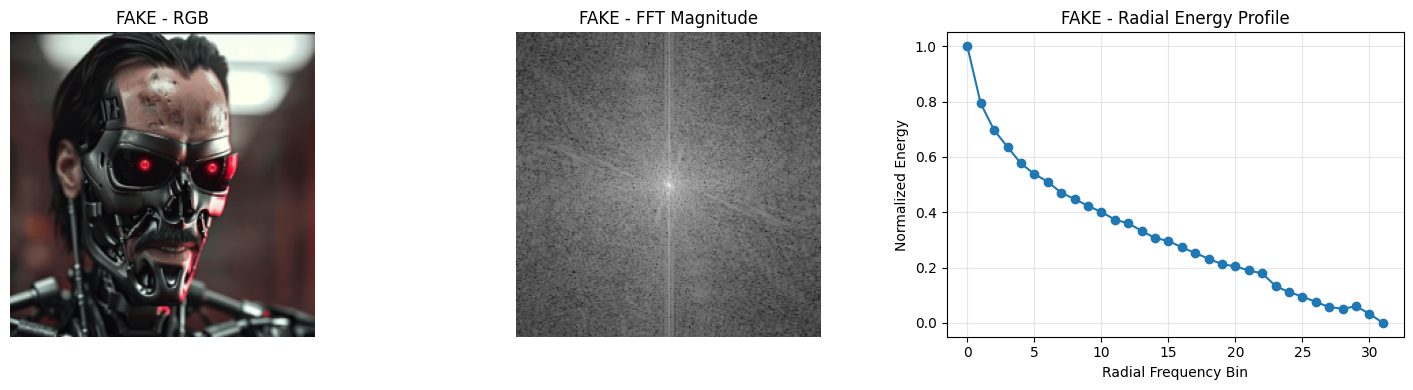

In [9]:
# ============================================================
# 10. Visual Sanity Check: RGB, FFT, and Radial Energy
# ============================================================

def show_rgb_fft_radial(dataframe, class_name):
    sample = dataframe[dataframe["class_name"] == class_name].sample(n=1, random_state=SEED).iloc[0]
    image_path = sample["image_path"]
    
    rgb_image = Image.open(image_path).convert("RGB").resize((224, 224))
    fft_image = image_to_fft_pil(image_path)
    radial_profile = compute_radial_energy_profile(image_path)
    
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_image)
    plt.title(f"{class_name.upper()} - RGB")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(fft_image)
    plt.title(f"{class_name.upper()} - FFT Magnitude")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.plot(radial_profile, marker="o")
    plt.title(f"{class_name.upper()} - Radial Energy Profile")
    plt.xlabel("Radial Frequency Bin")
    plt.ylabel("Normalized Energy")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

show_rgb_fft_radial(train_df, "real")
show_rgb_fft_radial(train_df, "fake")

In [10]:
# ============================================================
# 11. Image Transformations
# ============================================================

IMG_SIZE = 224

rgb_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rgb_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

fft_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("RGB and FFT transformations defined.")

RGB and FFT transformations defined.


In [11]:
# ============================================================
# 12. Hybrid RGB-FFT-Radial Dataset Class
# ============================================================

class HybridRGBFFTRadialDataset(Dataset):
    def __init__(self, dataframe, rgb_transform=None, fft_transform=None, num_radial_bins=32):
        self.dataframe = dataframe.reset_index(drop=True)
        self.rgb_transform = rgb_transform
        self.fft_transform = fft_transform
        self.num_radial_bins = num_radial_bins
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])
        
        rgb_image = Image.open(image_path).convert("RGB")
        fft_image = image_to_fft_pil(image_path)
        radial_profile = compute_radial_energy_profile(
            image_path,
            num_bins=self.num_radial_bins
        )
        
        if self.rgb_transform is not None:
            rgb_image = self.rgb_transform(rgb_image)
        
        if self.fft_transform is not None:
            fft_image = self.fft_transform(fft_image)
        
        radial_profile = torch.tensor(radial_profile, dtype=torch.float32)
        
        return rgb_image, fft_image, radial_profile, label

print("Hybrid RGB-FFT-Radial Dataset class created.")

Hybrid RGB-FFT-Radial Dataset class created.


In [12]:
# ============================================================
# 13. Create Hybrid RGB-FFT-Radial DataLoaders
# ============================================================

BATCH_SIZE = 32
NUM_RADIAL_BINS = 32

train_dataset = HybridRGBFFTRadialDataset(
    train_df,
    rgb_transform=rgb_train_transform,
    fft_transform=fft_transform,
    num_radial_bins=NUM_RADIAL_BINS
)

val_dataset = HybridRGBFFTRadialDataset(
    val_df,
    rgb_transform=rgb_eval_transform,
    fft_transform=fft_transform,
    num_radial_bins=NUM_RADIAL_BINS
)

test_dataset = HybridRGBFFTRadialDataset(
    test_df,
    rgb_transform=rgb_eval_transform,
    fft_transform=fft_transform,
    num_radial_bins=NUM_RADIAL_BINS
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Hybrid RGB-FFT-Radial DataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Hybrid RGB-FFT-Radial DataLoaders created successfully.
Training batches: 75
Validation batches: 25
Testing batches: 25


In [13]:
# ============================================================
# 14. DataLoader Sanity Check
# ============================================================

rgb_images, fft_images, radial_profiles, labels = next(iter(train_loader))

print("RGB batch shape:", rgb_images.shape)
print("FFT batch shape:", fft_images.shape)
print("Radial profile batch shape:", radial_profiles.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

RGB batch shape: torch.Size([32, 3, 224, 224])
FFT batch shape: torch.Size([32, 3, 224, 224])
Radial profile batch shape: torch.Size([32, 32])
Label batch shape: torch.Size([32])
Sample labels: [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]


# 4. Three-Branch RGB-FFT-Radial Fusion Architecture

This model contains three parallel branches:

## RGB Branch
A pretrained ResNet18 backbone extracts spatial-domain image features.

## FFT Branch
A lightweight CNN extracts visual patterns from the FFT magnitude spectrum.

## Radial Energy Branch
A small MLP processes the radial energy profile.

## Fusion
The three feature vectors are concatenated and passed through a compact classifier.

This model is inspired by spatial-frequency fusion research, especially FreqCross-style multi-branch detection.

In [14]:
# ============================================================
# 15. Three-Branch RGB-FFT-Radial Fusion Model
# ============================================================

class HybridRGBFFTRadialModel(nn.Module):
    def __init__(self, num_radial_bins=32, num_classes=2):
        super(HybridRGBFFTRadialModel, self).__init__()
        
        # ----------------------------
        # RGB Branch: ResNet18 Backbone
        # ----------------------------
        self.rgb_backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        rgb_features = self.rgb_backbone.fc.in_features
        self.rgb_backbone.fc = nn.Identity()
        
        # ----------------------------
        # FFT Branch: Lightweight CNN
        # ----------------------------
        self.fft_branch = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        fft_features = 128
        
        # ----------------------------
        # Radial Energy Branch: MLP
        # ----------------------------
        self.radial_branch = nn.Sequential(
            nn.Linear(num_radial_bins, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(inplace=True)
        )
        radial_features = 64
        
        # ----------------------------
        # Fusion Classifier
        # ----------------------------
        fusion_features = rgb_features + fft_features + radial_features
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, rgb_image, fft_image, radial_profile):
        rgb_features = self.rgb_backbone(rgb_image)
        
        fft_features = self.fft_branch(fft_image)
        fft_features = torch.flatten(fft_features, 1)
        
        radial_features = self.radial_branch(radial_profile)
        
        fused_features = torch.cat(
            [rgb_features, fft_features, radial_features],
            dim=1
        )
        
        output = self.classifier(fused_features)
        return output


radial_model = HybridRGBFFTRadialModel(
    num_radial_bins=NUM_RADIAL_BINS,
    num_classes=2
)

radial_model = radial_model.to(device)

print("Hybrid RGB-FFT-Radial fusion model created successfully.")
print("Model device:", next(radial_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Hybrid RGB-FFT-Radial fusion model created successfully.
Model device: cuda:0


In [15]:
# ============================================================
# 16. Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    radial_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


# 5. Training and Validation Functions

The model receives three inputs:

1. RGB image tensor
2. FFT magnitude image tensor
3. Radial energy profile vector

The model is trained using cross-entropy loss, and the best checkpoint is selected using validation accuracy.

In [16]:
# ============================================================
# 17. Training Function
# ============================================================

def train_one_epoch_radial(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for rgb_images, fft_images, radial_profiles, labels in dataloader:
        rgb_images = rgb_images.to(device)
        fft_images = fft_images.to(device)
        radial_profiles = radial_profiles.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(rgb_images, fft_images, radial_profiles)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

In [17]:
# ============================================================
# 18. Evaluation Function
# ============================================================

def evaluate_model_radial(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for rgb_images, fft_images, radial_profiles, labels in dataloader:
            rgb_images = rgb_images.to(device)
            fft_images = fft_images.to(device)
            radial_profiles = radial_profiles.to(device)
            labels = labels.to(device)
            
            outputs = model(rgb_images, fft_images, radial_profiles)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * labels.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy, all_labels, all_predictions

# 6. Model Training

The RGB-FFT-Radial fusion model is trained for 5 epochs.

This experiment tests whether radial energy distribution improves the spatial-frequency fusion model by providing a compact frequency-domain descriptor.

In [18]:
# ============================================================
# 19. Train RGB-FFT-Radial Fusion Model
# ============================================================

NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_path = "/kaggle/working/best_hybrid_rgb_fft_radial_model.pth"

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_one_epoch_radial(
        radial_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model_radial(
        radial_model,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(radial_model.state_dict(), best_model_path)
        print("Best RGB-FFT-Radial model saved.")

end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed.")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/5
------------------------------
Train Loss: 0.4743 | Train Accuracy: 0.7721
Val Loss:   0.3264 | Val Accuracy:   0.8575
Best RGB-FFT-Radial model saved.

Epoch 2/5
------------------------------
Train Loss: 0.2956 | Train Accuracy: 0.8808
Val Loss:   0.3101 | Val Accuracy:   0.8688
Best RGB-FFT-Radial model saved.

Epoch 3/5
------------------------------
Train Loss: 0.2238 | Train Accuracy: 0.9029
Val Loss:   0.3793 | Val Accuracy:   0.8488

Epoch 4/5
------------------------------
Train Loss: 0.1652 | Train Accuracy: 0.9337
Val Loss:   0.3551 | Val Accuracy:   0.8725
Best RGB-FFT-Radial model saved.

Epoch 5/5
------------------------------
Train Loss: 0.1329 | Train Accuracy: 0.9496
Val Loss:   0.3620 | Val Accuracy:   0.8725

Training completed.
Best Validation Accuracy: 0.8725
Training Time: 39.37 minutes


# 7. Test Set Evaluation

The best RGB-FFT-Radial model checkpoint is loaded and evaluated on the unseen test set.

This test result will show whether adding radial energy distribution improves performance compared with:

- RGB-only baseline
- FFT-only baseline
- RGB-FFT fusion model

In [19]:
# ============================================================
# 20. Load Best RGB-FFT-Radial Model and Evaluate on Test Set
# ============================================================

radial_model.load_state_dict(torch.load(best_model_path, map_location=device))
radial_model = radial_model.to(device)

test_loss, test_acc, test_labels, test_preds = evaluate_model_radial(
    radial_model,
    test_loader,
    criterion,
    device
)

print("RGB-FFT-Radial test evaluation completed.")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

RGB-FFT-Radial test evaluation completed.
Test Loss:     0.3186
Test Accuracy: 0.8688


# 8. Classification Metrics

The RGB-FFT-Radial model is evaluated using the same metrics as all previous models:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Using the same evaluation metrics ensures fair comparison across all experiments.

In [20]:
# ============================================================
# 21. Classification Metrics
# ============================================================

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print("Final RGB-FFT-Radial Test Metrics:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Real", "Fake"]
))

Final RGB-FFT-Radial Test Metrics:
Accuracy : 0.8688
Precision: 0.9155
Recall   : 0.8125
F1-score : 0.8609

Classification Report:
              precision    recall  f1-score   support

        Real       0.83      0.93      0.88       400
        Fake       0.92      0.81      0.86       400

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800



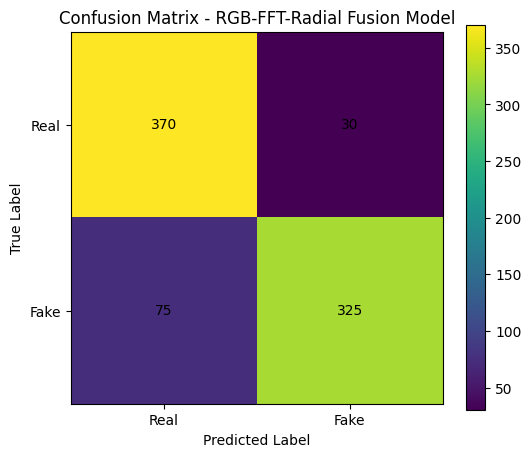

Confusion Matrix:
[[370  30]
 [ 75 325]]


In [27]:
# ============================================================
# 22. Confusion Matrix
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - RGB-FFT-Radial Fusion Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

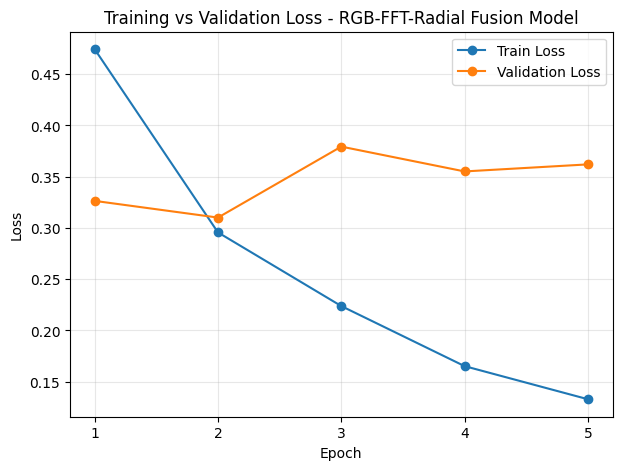

In [29]:
# ============================================================
# 23. Training and Validation Loss Curve
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss - RGB-FFT-Radial Fusion Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 24. Training and Validation Accuracy Curve
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy - RGB-FFT-Radial Fusion Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [31]:
# ============================================================
# 25. Save RGB-FFT-Radial Results
# ============================================================

results = {
    "model": ["Hybrid_RGB_FFT_Radial_Fusion"],
    "input_type": ["RGB + FFT_Magnitude + Radial_Energy"],
    "best_val_accuracy": [best_val_accuracy],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1_score": [test_f1],
    "test_loss": [test_loss],
    "epochs": [NUM_EPOCHS],
    "training_time_minutes": [training_time / 60]
}

results_df = pd.DataFrame(results)

results_path = "/kaggle/working/hybrid_rgb_fft_radial_results.csv"
results_df.to_csv(results_path, index=False)

print("RGB-FFT-Radial results saved successfully.")
print(results_df)

RGB-FFT-Radial results saved successfully.
                          model                           input_type  \
0  Hybrid_RGB_FFT_Radial_Fusion  RGB + FFT_Magnitude + Radial_Energy   

   best_val_accuracy  test_accuracy  test_precision  test_recall  \
0             0.8725        0.86875        0.915493       0.8125   

   test_f1_score  test_loss  epochs  training_time_minutes  
0       0.860927   0.318592       5              39.369281  


In [32]:
# ============================================================
# 26. Save RGB-FFT-Radial Training History
# ============================================================

history_df = pd.DataFrame(history)
history_df["epoch"] = range(1, NUM_EPOCHS + 1)

history_path = "/kaggle/working/hybrid_rgb_fft_radial_training_history.csv"
history_df.to_csv(history_path, index=False)

print("RGB-FFT-Radial training history saved successfully.")
print(history_df)

RGB-FFT-Radial training history saved successfully.
   train_loss  train_accuracy  val_loss  val_accuracy  epoch
0    0.474321        0.772083  0.326372       0.85750      1
1    0.295617        0.880833  0.310085       0.86875      2
2    0.223788        0.902917  0.379331       0.84875      3
3    0.165185        0.933750  0.355101       0.87250      4
4    0.132902        0.949583  0.361978       0.87250      5


# 9. Result Interpretation

The RGB-FFT-Radial fusion model achieved a best validation accuracy of 87.25%.

## Key Observation

Adding the radial energy branch produced a stronger result than the FFT-only baseline, but it did not outperform the RGB-only baseline in this experiment.

## Interpretation

This result suggests that structured frequency information such as radial energy distribution can provide meaningful auxiliary information, but the current lightweight fusion design may not be strong enough to fully exploit it.

The result also supports an important research conclusion:

- Raw FFT magnitude alone overfits heavily.
- RGB spatial features remain the strongest standalone representation.
- Frequency-based features may require careful feature design, regularization, or advanced fusion methods to consistently improve performance.

## Paper-Inspired Discussion

The result is consistent with the motivation behind spatial-frequency fusion papers: frequency information is useful, but it should not simply replace spatial information. Instead, it should be treated as a complementary representation.

In this project, the radial energy branch completes a paper-inspired ablation study by comparing:

1. RGB-only model
2. FFT-only model
3. RGB-FFT fusion model
4. RGB-FFT-Radial fusion model